In [42]:
import secrets
import os
import pathlib
import base64

In [43]:
def gerar_chave(tamanho: int) -> bytes:
    """Gera uma chave criptograficamente segura com tamanho bytes."""
    chave_gerada_aleatoriamente = secrets.token_bytes(tamanho)
    return chave_gerada_aleatoriamente

def xor_bytes(dados: bytes, chave: bytes) -> bytes:
    """Calcula o XOR entre sequencias de mesmo comprimento."""
    if(len(dados)==len(chave)):
        # resultado_xor = bytearray()
        resultado_xor = []
        for i in range(len(dados)):
            resultado_xor.append(dados[i]^chave[i]) 
        return bytes(resultado_xor) #melhor deixar a conversão de bytes aqui já e resolver mais bunitinho do que antes
    else:
        raise ValueError("Erro! Tamanhos diferentes entre dados e chave!")


def cifrar(mensagem: bytes, chave: bytes) -> bytes:
    """Cifra mensagem usando OTP."""
    if(len(mensagem)==len(chave)):
        cifrado_calculado = xor_bytes(mensagem,chave)
        return cifrado_calculado
    else:
        raise ValueError("Erro! Tamanhos diferentes entre mensagem e chave!")

def decifrar(cifrado: bytes, chave: bytes) -> bytes:
    """Decifra um texto cifrado usando OTP."""
    if(len(cifrado)==len(chave)):
        mensagem_decifrada = xor_bytes(cifrado,chave)
        return mensagem_decifrada
    else:
        raise ValueError("Erro! Tamanhos diferentes entre cifrado e chave!")

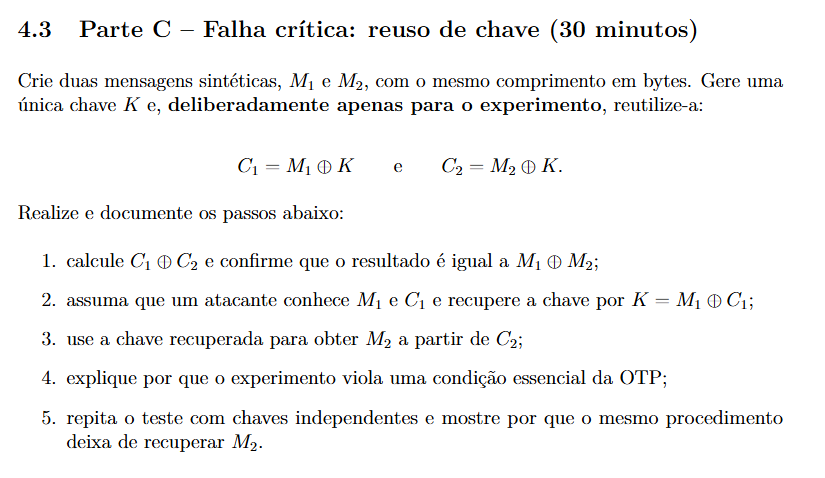

In [44]:
caminho_msg_test = "materiais_laboratorio_L1_OTP/materiais_l1_otp/mensagens_teste.txt"
with open(caminho_msg_test, "r") as f:
    for line in f:
        if "M1:" in line:
            mensagem_1 = line.split("M1: ")[1].strip() # strip é pq notei um /n doideira...
        if "M2:" in line:
            mensagem_2 = line.split("M2: ")[1].strip()
        
print(mensagem_1)
print(mensagem_2)

REUNIAO NA SALA 2077 AS TREZE HORAS. LEVE O RELATORIO L1.
SEMINAR NA SALA 3013 AS TREZE HORAS. LEVE O SEU NOTEBOOK.


In [45]:
mensagem_1_bytes = mensagem_1.encode('utf-8')
mensagem_2_bytes = mensagem_2.encode('utf-8')

print(f"Mensagem 1 (bytes): {mensagem_1_bytes}")
print(f"Mensagem 2 (bytes): {mensagem_2_bytes}")
print(f"Mensagem 1 (tamanho em chars): {len(mensagem_1)}")
print(f"Mensagem 1 (tamanho em bytes): {len(mensagem_1_bytes)}")

chave_two_time_pad = gerar_chave(len(mensagem_1_bytes))
print(f"Chave (bytes): {chave_two_time_pad}")
print(f"Chave (tamanho em bytes): {len(chave_two_time_pad)}")

Mensagem 1 (bytes): b'REUNIAO NA SALA 2077 AS TREZE HORAS. LEVE O RELATORIO L1.'
Mensagem 2 (bytes): b'SEMINAR NA SALA 3013 AS TREZE HORAS. LEVE O SEU NOTEBOOK.'
Mensagem 1 (tamanho em chars): 57
Mensagem 1 (tamanho em bytes): 57
Chave (bytes): b'\x97/A\xc3T\xeb\xb4\xfd\r\xb1\xb3\xa1\xc5\xe8\x0e\x1a@\xc4\x17\x85\x04h\xc3l`\xd32\x1d\x9b\x01oX\xe9\xa3lWD$\xe1rJKP\xafZ\xf6\x92\x17\xc9\x85\xbd\xbe&\x92\xaf\xa5\x0e'
Chave (tamanho em bytes): 57


In [46]:
cifra_1 = cifrar(mensagem_1_bytes, chave_two_time_pad) # C1 = M1 ⊕ K
cifra_2 = cifrar(mensagem_2_bytes, chave_two_time_pad) # C2 = M2 ⊕ K

print(f"Cifra 1 (bytes): {cifra_1}") 
print(f"Cifra 2 (bytes): {cifra_2}")

Cifra 1 (bytes): b"\xc5j\x14\x8d\x1d\xaa\xfb\xddC\xf0\x93\xf2\x84\xa4O:r\xf4 \xb2$)\x90L4\x81wG\xde!'\x17\xbb\xe2?ydh\xa4$\x0fk\x1f\x8f\x08\xb3\xdeV\x9d\xca\xef\xf7i\xb2\xe3\x94 "
Cifra 2 (bytes): b"\xc4j\x0c\x8a\x1a\xaa\xe6\xddC\xf0\x93\xf2\x84\xa4O:s\xf4&\xb6$)\x90L4\x81wG\xde!'\x17\xbb\xe2?ydh\xa4$\x0fk\x1f\x8f\t\xb3\xc77\x87\xca\xe9\xfbd\xdd\xe0\xee "


In [47]:
c1_x_c2 = xor_bytes(cifra_1,cifra_2) # c1_x_c2 = C1 ⊕ C2
M1_x_M2 = xor_bytes(mensagem_1_bytes,mensagem_2_bytes) # M1_x_M2 = M1 ⊕ M2

print(f"C1 ⊕ C2 = {c1_x_c2}")
print(f"M1 ⊕ M2 = {M1_x_M2}")

if(c1_x_c2==M1_x_M2):
    print("Sim! Os valores de C1 ⊕ C2 e M1 ⊕ M2 são iguais. Falha pelo Two Time Pad...")
else:
    print("Não! Eles não são iguais.")


# C1 ⊕ C2 = (M1 ⊕ K) ⊕ (M2 ⊕ K)
#          = M1 ⊕ M2 ⊕ K ⊕ K
#          = M1 ⊕ M2 ⊕ 0
#          = M1 ⊕ M2

C1 ⊕ C2 = b'\x01\x00\x18\x07\x07\x00\x1d\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x06\x04\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x19a\x1a\x00\x06\x0c\ro\x03z\x00'
M1 ⊕ M2 = b'\x01\x00\x18\x07\x07\x00\x1d\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x06\x04\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x19a\x1a\x00\x06\x0c\ro\x03z\x00'
Sim! Os valores de C1 ⊕ C2 e M1 ⊕ M2 são iguais. Falha pelo Two Time Pad...


In [48]:
chave_reencontrada_ataq = xor_bytes(mensagem_1_bytes,cifra_1) # K = M1 ⊕ C1

print(f"Chave criada pelo sistema:                           {chave_two_time_pad}")
print(f"Chave descoberta pelo atacante por conhecer M1 e C1: {chave_reencontrada_ataq}")

if(chave_reencontrada_ataq==chave_two_time_pad):
    print("Sim! O valor da Chave criada pelo sistema é igual ao valor da Chave obtida pelo ataque. Tudo pelo atacante conhecer M1 e C1... Problemão em")
else:
    print("Não! Elas não são iguais.")

# M1 ⊕ C1 = M1 ⊕ M1 ⊕ K
#          = (M1 ⊕ M1) ⊕ K
#          = K

Chave criada pelo sistema:                           b'\x97/A\xc3T\xeb\xb4\xfd\r\xb1\xb3\xa1\xc5\xe8\x0e\x1a@\xc4\x17\x85\x04h\xc3l`\xd32\x1d\x9b\x01oX\xe9\xa3lWD$\xe1rJKP\xafZ\xf6\x92\x17\xc9\x85\xbd\xbe&\x92\xaf\xa5\x0e'
Chave descoberta pelo atacante por conhecer M1 e C1: b'\x97/A\xc3T\xeb\xb4\xfd\r\xb1\xb3\xa1\xc5\xe8\x0e\x1a@\xc4\x17\x85\x04h\xc3l`\xd32\x1d\x9b\x01oX\xe9\xa3lWD$\xe1rJKP\xafZ\xf6\x92\x17\xc9\x85\xbd\xbe&\x92\xaf\xa5\x0e'
Sim! O valor da Chave criada pelo sistema é igual ao valor da Chave obtida pelo ataque. Tudo pelo atacante conhecer M1 e C1... Problemão em


In [49]:
mensagem_2_recuperada_atacante_chave_recuperada = xor_bytes(cifra_2, chave_reencontrada_ataq)

print(f"M2 recuperada pelo atacante: {mensagem_2_recuperada_atacante_chave_recuperada}")
print(f"M2 original:                 {mensagem_2_bytes}")


if(mensagem_2_recuperada_atacante_chave_recuperada==mensagem_2_bytes):
    print("Sim! O atacante, infelizmente, conseguiu recuperar a mensagem 2 a partir da K obtida no ataque anterior e a cifra 2 interceptada... Vish")
else:
    print("Não! Elas não são iguais.")


# C2 ⊕ K = M2 ⊕ K ⊕ K
#         = M2 ⊕ (K ⊕ K)
#         = M2

M2 recuperada pelo atacante: b'SEMINAR NA SALA 3013 AS TREZE HORAS. LEVE O SEU NOTEBOOK.'
M2 original:                 b'SEMINAR NA SALA 3013 AS TREZE HORAS. LEVE O SEU NOTEBOOK.'
Sim! O atacante, infelizmente, conseguiu recuperar a mensagem 2 a partir da K obtida no ataque anterior e a cifra 2 interceptada... Vish


O experimento viola a regra de ouro do algoritmo One-Time Pad (OTP): a chave deve ser usada única e exclusivamente para uma única mensagem e depois descartada. A segurança perfeita do OTP depende da aleatoriedade absoluta da chave para ocultar a mensagem. No entanto, quando reutilizamos a mesma chave para cifrar duas mensagens diferentes ($C_1$ e $C_2$), criamos uma vulnerabilidade matemática gravíssima. Como a operação XOR é reversível e cancela valores duplicados, ao realizarmos o XOR entre os dois textos cifrados ($C_1 \oplus C_2$), a chave idêntica se anula, deixando como resultado o XOR das duas mensagens em texto claro ($M_1 \oplus M_2$). A partir desse momento, a proteção da chave deixa de existir. Se um atacante descobrir ou deduzir o conteúdo de apenas uma das mensagens, ele pode aplicar a operação XOR para extrair a chave original e, consequentemente, quebrar o sigilo de todas as outras mensagens que compartilharam essa mesma chave.

---

Refazendo para K1 e K2 diferentes

In [50]:
caminho_msg_test = "materiais_laboratorio_L1_OTP/materiais_l1_otp/mensagens_teste.txt"
with open(caminho_msg_test, "r") as f:
    for line in f:
        if "M1:" in line:
            mensagem_1 = line.split("M1: ")[1].strip() # strip é pq notei um /n doideira...
        if "M2:" in line:
            mensagem_2 = line.split("M2: ")[1].strip()
        
print(mensagem_1)
print(mensagem_2)

REUNIAO NA SALA 2077 AS TREZE HORAS. LEVE O RELATORIO L1.
SEMINAR NA SALA 3013 AS TREZE HORAS. LEVE O SEU NOTEBOOK.


In [51]:
mensagem_1_bytes = mensagem_1.encode('utf-8')
mensagem_2_bytes = mensagem_2.encode('utf-8')

print(f"Mensagem 1 (bytes): {mensagem_1_bytes}")
print(f"Mensagem 2 (bytes): {mensagem_2_bytes}")
print(f"Mensagem 1 (tamanho em chars): {len(mensagem_1)}")
print(f"Mensagem 1 (tamanho em bytes): {len(mensagem_1_bytes)}")

chave_k1 = gerar_chave(len(mensagem_1_bytes))
chave_k2 = gerar_chave(len(mensagem_2_bytes))
print(f"Chave K1 (bytes): {chave_k1}")
print(f"Chave K1 (tamanho em bytes): {len(chave_k1)}")
print(f"Chave K2 (bytes): {chave_k2}")
print(f"Chave K2 (tamanho em bytes): {len(chave_k2)}")

Mensagem 1 (bytes): b'REUNIAO NA SALA 2077 AS TREZE HORAS. LEVE O RELATORIO L1.'
Mensagem 2 (bytes): b'SEMINAR NA SALA 3013 AS TREZE HORAS. LEVE O SEU NOTEBOOK.'
Mensagem 1 (tamanho em chars): 57
Mensagem 1 (tamanho em bytes): 57
Chave K1 (bytes): b'\x96\xdf\x87\x87\x15\x9b\x84\x7f\xe5\x94\xdf\x19JL\x9c,gW\x1c\xfe\xb5J\x04N|bB\xd8\xb6i\x9b\r\x92YA\x15\xbb\xdb\xe4\xba_\xd4\x8c+p=\xafD\xfa[\r-\xf3u\x14\x160'
Chave K1 (tamanho em bytes): 57
Chave K2 (bytes): b'\xd7\xee\x0f\x03N\xbbQ\xb7tz\xf9R\x1f\x15}V\xf5\xefDb@\x85E\xec\xd4H\x8c\x98\x00\xe2~\x80\xd1\xb1\xe2\xf6\xdf\xbb\xff\xb8\xe3\xdae\x1b\xf1\x85\xc2K\x1e\xb0!\xab\xa6k\x83\xc9\xd9'
Chave K2 (tamanho em bytes): 57


In [ ]:
cifra_1_chave1 = cifrar(mensagem_1_bytes, chave_k1) # C1 = M1 ⊕ K1
cifra_2_chave2 = cifrar(mensagem_2_bytes, chave_k2) # C2 = M2 ⊕ K2

print(f"Cifra 1 (bytes): {cifra_1_chave1}") 
print(f"Cifra 2 (bytes): {cifra_2_chave2}")

Cifra 1 (bytes): b'\xc4\x9a\xd2\xc9\\\xda\xcb_\xab\xd5\xffJ\x0b\x00\xdd\x0cUg+\xc9\x95\x0bWn(0\x07\x82\xf3I\xd3B\xc0\x18\x12;\x9b\x97\xa1\xec\x1a\xf4\xc3\x0b"x\xe3\x05\xae\x14_d\xbcUX\'\x1e'
Cifra 2 (bytes): b'\x84\xabBJ\x00\xfa\x03\x97:;\xd9\x01^Y<v\xc6\xdfuQ`\xc4\x16\xcc\x80\x1a\xc9\xc2E\xc26\xcf\x83\xf0\xb1\xd8\xff\xf7\xba\xee\xa6\xfa*;\xa2\xc0\x97kP\xffu\xee\xe4$\xcc\x82\xf7'


In [ ]:
c1_x_c2 = xor_bytes(cifra_1_chave1,cifra_2_chave2) # c1_x_c2 = C1 ⊕ C2
M1_x_M2 = xor_bytes(mensagem_1_bytes,mensagem_2_bytes) # M1_x_M2 = M1 ⊕ M2

print(f"C1 ⊕ C2 = {c1_x_c2}")
print(f"M1 ⊕ M2 = {M1_x_M2}")

if(c1_x_c2==M1_x_M2):
    print("Sim! Os valores de C1 ⊕ C2 e M1 ⊕ M2 são iguais. Falha pelo Two Time Pad...")
else:
    print("Não! Eles não são iguais.")


# C1 ⊕ C2 = (M1 ⊕ K1) ⊕ (M2 ⊕ K2)
#          = M1 ⊕ M2 ⊕ K1 ⊕ K2
#          = Consigo fazer nada...

C1 ⊕ C2 = b'@1\x90\x83\\ \xc8\xc8\x91\xee&KUY\xe1z\x93\xb8^\x98\xf5\xcfA\xa2\xa8*\xce@\xb6\x8b\xe5\x8dC\xe8\xa3\xe3d`\x1b\x02\xbc\x0e\xe90\x80\xb8tn\xfe\xeb*\x8aXq\x94\xa5\xe9'
M1 ⊕ M2 = b'\x01\x00\x18\x07\x07\x00\x1d\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x06\x04\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x19a\x1a\x00\x06\x0c\ro\x03z\x00'
Não! Eles não são iguais.


In [ ]:
# Esse ataque é com M1 ⊕ C1 para obter K1, por isso falha. Como para a M2 já tenho outra chave K2 o ataque falhará em C2.

chave_reencontrada_ataq_1 = xor_bytes(mensagem_1_bytes,cifra_1_chave1) # K1 = M1 ⊕ C1
# chave_reencontrada_ataq_2 = xor_bytes(mensagem_2_bytes,cifra_2_chave2) # K2 = M2 ⊕ C2

print(f"Chave criada pelo sistema:                           {chave_k1}")
print(f"Chave descoberta pelo atacante por conhecer M1 e C1: {chave_reencontrada_ataq_1}")
# print(f"Chave criada pelo sistema:                           {chave_k2}")
# print(f"Chave descoberta pelo atacante por conhecer M1 e C1: {chave_reencontrada_ataq_2}")

if(chave_reencontrada_ataq_1==chave_k1):
    print("Sim! O valor da Chave criada pelo sistema é igual ao valor da Chave obtida pelo ataque. Tudo pelo atacante conhecer M1 e C1... Será um problema para M2 ?")
else:
    print("Não! Elas não são iguais.")

# M1 ⊕ C1 = M1 ⊕ M1 ⊕ K1
#          = (M1 ⊕ M1) ⊕ K1
#          = K1

Chave criada pelo sistema:                           b'\x96\xdf\x87\x87\x15\x9b\x84\x7f\xe5\x94\xdf\x19JL\x9c,gW\x1c\xfe\xb5J\x04N|bB\xd8\xb6i\x9b\r\x92YA\x15\xbb\xdb\xe4\xba_\xd4\x8c+p=\xafD\xfa[\r-\xf3u\x14\x160'
Chave descoberta pelo atacante por conhecer M1 e C1: b'\x96\xdf\x87\x87\x15\x9b\x84\x7f\xe5\x94\xdf\x19JL\x9c,gW\x1c\xfe\xb5J\x04N|bB\xd8\xb6i\x9b\r\x92YA\x15\xbb\xdb\xe4\xba_\xd4\x8c+p=\xafD\xfa[\r-\xf3u\x14\x160'
Sim! O valor da Chave criada pelo sistema é igual ao valor da Chave obtida pelo ataque. Tudo pelo atacante conhecer M1 e C1... Será um problema para M2 ?


In [59]:
mensagem_2_recuperada_atacante_chave_recuperada = xor_bytes(cifra_2_chave2, chave_reencontrada_ataq_1)

print(f"M2 recuperada pelo atacante: {mensagem_2_recuperada_atacante_chave_recuperada}")
print(f"M2 original:                 {mensagem_2_bytes}")


if(mensagem_2_recuperada_atacante_chave_recuperada==mensagem_2_bytes):
    print("Sim! O atacante, infelizmente, conseguiu recuperar a mensagem 2 a partir da K obtida no ataque anterior e a cifra 2 interceptada... Vish")
else:
    print("Não! Elas não são iguais. Ele obteve só um lixo de bytes ali...")


# C2 ⊕ K1 = M2 ⊕ K2 ⊕ K1
#         = Não consigo fazer nada ... Chaves são diferentes ...

M2 recuperada pelo atacante: b'\x12t\xc5\xcd\x15a\x87\xe8\xdf\xaf\x06\x18\x14\x15\xa0Z\xa1\x88i\xaf\xd5\x8e\x12\x82\xfcx\x8b\x1a\xf3\xab\xad\xc2\x11\xa9\xf0\xcdD,^T\xf9.\xa6\x10\xd2\xfd8/\xaa\xa4x\xc3\x17Q\xd8\x94\xc7'
M2 original:                 b'SEMINAR NA SALA 3013 AS TREZE HORAS. LEVE O SEU NOTEBOOK.'
Não! Elas não são iguais. Ele obteve só um lixo de bytes ali...


O experimento anterior demonstrou que, ao reutilizar a mesma chave K para cifrar duas
mensagens diferentes, um atacante que conhece M1 e C1 consegue recuperar K e, com ela,
decifrar C2. Essa vulnerabilidade é conhecida como Two-Time Pad.

Nesta etapa, demonstra-se o comportamento oposto: quando cada mensagem é cifrada com
uma chave independente, o ataque falha. Mesmo que o atacante possua M1 e C1, conseguindo
recuperar K1, essa chave não guarda nenhuma relação com K2. Portanto, ao tentar decifrar
C2 com K1, o resultado é:

    C2 ⊕ K1 = (M2 ⊕ K2) ⊕ K1 = M2 ⊕ K2 ⊕ K1

Como K1 e K2 são aleatórias e independentes, a expressão M2 ⊕ K2 ⊕ K1 produz apenas
uma sequência de bytes sem sentido, sem nenhuma informação recuperável sobre M2.

Esse resultado ilustra a condição essencial do One-Time Pad: cada chave deve ser utilizada
uma única vez. O uso de chaves distintas por mensagem garante que o vazamento de uma
chave não comprometa a segurança das demais mensagens. É exatamente essa propriedade que
torna o OTP teoricamente inquebrável, desde que suas condições de uso sejam respeitadas.
